In [1]:
!pip install pandas
!pip install numpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("../data/data_part2.csv")

# Обработка

In [4]:
data.head()

,Название,Цена,Дата,Телефон,Оператор,Контактное лицо (автор объявления),Тип автора,Регион,Город,Метро/Район,...,Источник,lat,lng,Персона для контактов,Доп.параметры,URL,Ссылки на картинки,Регион мобильного телефона,Номер подменён,"Расстояние до метро, км"
0,"Торговая площадь в Московская область, Ленинск...",600000,2025-10-19 22:29:04,89166030204,Мобильные ТелеСистемы,Малина Проперти,Агентство,Московская область,Ленинский городской округ,Домодедовская,...,cian.ru,55.555520,37.811267,NaN,Этаж=1|Этажность здания=17|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,г. Москва и Московская область,да,12.833
1,Производственное помещение в Московская област...,2349809,2025-10-19 22:29:03,89862742715,не определен,Андрей Хмелевский (Апекс-Недвижимость),Агентство,Московская область,Пушкино,Мамонтовка,...,cian.ru,56.002249,37.800631,NaN,Этаж=1|Этажность здания=2|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/318910625,https://images.cdn-cian.ru/images/2531003819-1...,не определен,да,неизвестно
2,Помещение свободного назначения в Московская о...,200000,2025-10-19 22:28:45,89153024839,Мобильные ТелеСистемы,Белые Паруса,Агентство,Московская область,Подольск,Подольск,...,cian.ru,55.421910,37.572369,NaN,Этаж=1|Этажность здания=4|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,г. Москва и Московская область,да,1.5
3,"Коммерческая земля в Московская область, Дмитр...",51000,2025-10-19 22:28:42,89101553467,Мобильные ТелеСистемы,ГИС Торги,Агентство,Московская область,Дмитровский муниципальный округ,NaN,...,cian.ru,56.437228,37.061138,NaN,Ед. измерения площади=сот.|Категория=Участок п...,https://www.cian.ru/rent/commercial/322939017,https://images.cdn-cian.ru/images/2667463412-1...,Тульская область,да,неизвестно
4,"Коммерческая земля в Московская область, Дмитр...",46750,2025-10-19 22:28:42,89101553467,Мобильные ТелеСистемы,ГИС Торги,Агентство,Московская область,Дмитровский муниципальный округ,NaN,...,cian.ru,56.437228,37.061138,NaN,Ед. измерения площади=сот.|Категория=Участок п...,https://www.cian.ru/rent/commercial/322939018,https://images.cdn-cian.ru/images/2667463474-1...,Тульская область,да,неизвестно


In [5]:
data.isna().sum()

Название                                  0
Цена                                      0
Дата                                      0
Телефон                                   0
Оператор                                  0
Контактное лицо (автор объявления)      102
Тип автора                                0
Регион                                    0
Город                                     0
Метро/Район                            7186
Адрес                                  3529
Описание                                328
Тип объявления                            0
Категория1                                0
Категория2                                0
ID на сайте                               0
Источник                                  0
lat                                       0
lng                                       0
Персона для контактов                 20000
Доп.параметры                             0
URL                                       0
Ссылки на картинки              

In [6]:
data.columns

Index(['Название', 'Цена', 'Дата', 'Телефон', 'Оператор',
       'Контактное лицо (автор объявления)', 'Тип автора', 'Регион', 'Город',
       'Метро/Район', 'Адрес', 'Описание', 'Тип объявления', 'Категория1',
       'Категория2', 'ID на сайте', 'Источник', 'lat', 'lng',
       'Персона для контактов', 'Доп.параметры', 'URL', 'Ссылки на картинки',
       'Регион мобильного телефона', 'Номер подменён',
       'Расстояние до метро, км'],
      dtype='object')

In [7]:
data = data.drop(['Телефон', 'Оператор', 'Контактное лицо (автор объявления)',
           'Номер подменён', 'Персона для контактов', 'Регион мобильного телефона',
           'Тип объявления', 'Категория1', 'Категория2'
], axis=1)

In [8]:
data.head()

,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,ID на сайте,Источник,lat,lng,Доп.параметры,URL,Ссылки на картинки,"Расстояние до метро, км"
0,"Торговая площадь в Московская область, Ленинск...",600000,2025-10-19 22:29:04,Агентство,Московская область,Ленинский городской округ,Домодедовская,"ш. Пригородное, 24","Аренда торгового помещения 229,7 м2 в пгт.Миса...",320933693,cian.ru,55.555520,37.811267,Этаж=1|Этажность здания=17|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,12.833
1,Производственное помещение в Московская област...,2349809,2025-10-19 22:29:03,Агентство,Московская область,Пушкино,Мамонтовка,"Мамонтовка мкр, Рабочая ул., 1к1",Лот 871949 Предложение от Собственника Предла...,318910625,cian.ru,56.002249,37.800631,Этаж=1|Этажность здания=2|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/318910625,https://images.cdn-cian.ru/images/2531003819-1...,неизвестно
2,Помещение свободного назначения в Московская о...,200000,2025-10-19 22:28:45,Агентство,Московская область,Подольск,Подольск,"ул. Мира, 7",Прямая аренда от собственника Предлагается в ...,320821721,cian.ru,55.421910,37.572369,Этаж=1|Этажность здания=4|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,1.5
3,"Коммерческая земля в Московская область, Дмитр...",51000,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,Данные получены с сайта ГИС Торги. право заклю...,322939017,cian.ru,56.437228,37.061138,Ед. измерения площади=сот.|Категория=Участок п...,https://www.cian.ru/rent/commercial/322939017,https://images.cdn-cian.ru/images/2667463412-1...,неизвестно
4,"Коммерческая земля в Московская область, Дмитр...",46750,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,Данные получены с сайта ГИС Торги. право заклю...,322939018,cian.ru,56.437228,37.061138,Ед. измерения площади=сот.|Категория=Участок п...,https://www.cian.ru/rent/commercial/322939018,https://images.cdn-cian.ru/images/2667463474-1...,неизвестно


In [9]:
data = data.set_index(['ID на сайте', 'Источник'])

In [10]:
data.loc[(320933693, "cian.ru")]

Название                   Торговая площадь в Московская область, Ленинск...
Цена                                                                  600000
Дата                                                     2025-10-19 22:29:04
Тип автора                                                         Агентство
Регион                                                    Московская область
Город                                              Ленинский городской округ
Метро/Район                                                    Домодедовская
Адрес                                                     ш. Пригородное, 24
Описание                   Аренда торгового помещения 229,7 м2 в пгт.Миса...
lat                                                                 55.55552
lng                                                                37.811267
Доп.параметры              Этаж=1|Этажность здания=17|Тип объявления=Сдам...
URL                            https://www.cian.ru/rent/commercial/320933693

In [11]:
data['Описание'] = 'НАЗВАНИЕ: ' + data['Название'] + '\n\n' + 'ОПИСАНИЕ: ' + data['Описание']

In [12]:
print(data.loc[(320933693, "cian.ru"), "Описание"])

НАЗВАНИЕ: Торговая площадь в Московская область, Ленинский городской округ, Мисайлово пгт ш. Пригородное, 24 (231 м²)

ОПИСАНИЕ: Аренда торгового помещения 229,7 м2 в пгт.Мисайлово, Пригородное шоссе, д. 24 (15 минут транспортом от метро Зябликово). 1-я линия домов. Помещение 229,7 м2 располагается на 1 этаже, открытая планировка, отдельный вход с фасада на Литературный бульвар и один со двора, высота потолка 4 м, витринные окна по фасаду. Электрическая мощность 45 кВт. Помещение в бетоне. Парковка перед фасадом. Место для размещения рекламы на фасаде. Две мокрые точки. Помещение расположено в жилом комплексе  Пригород лесное . Напротив помещения расположена государственная поликлиника. Поликлиника во всем микрорайоне (в том числе существующая часть микрорайона) будет одна. Уже построена. Больше 100 метров от входа до входа. Прямая аренда от собственника, долгосрочный договор. Арендная плата 600 000 рублей в месяц. УС налогообложения. Без комиссии.


In [13]:
data.drop('Название', axis=1)

,,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,Доп.параметры,URL,Ссылки на картинки,"Расстояние до метро, км"
ID на сайте,Источник,,,,,,,,,,,,,,
320933693,cian.ru,600000,2025-10-19 22:29:04,Агентство,Московская область,Ленинский городской округ,Домодедовская,"ш. Пригородное, 24",НАЗВАНИЕ: Торговая площадь в Московская област...,55.555520,37.811267,Этаж=1|Этажность здания=17|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,12.833
318910625,cian.ru,2349809,2025-10-19 22:29:03,Агентство,Московская область,Пушкино,Мамонтовка,"Мамонтовка мкр, Рабочая ул., 1к1",НАЗВАНИЕ: Производственное помещение в Московс...,56.002249,37.800631,Этаж=1|Этажность здания=2|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/318910625,https://images.cdn-cian.ru/images/2531003819-1...,неизвестно
320821721,cian.ru,200000,2025-10-19 22:28:45,Агентство,Московская область,Подольск,Подольск,"ул. Мира, 7",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.421910,37.572369,Этаж=1|Этажность здания=4|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,1.5
322939017,cian.ru,51000,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,Ед. измерения площади=сот.|Категория=Участок п...,https://www.cian.ru/rent/commercial/322939017,https://images.cdn-cian.ru/images/2667463412-1...,неизвестно
322939018,cian.ru,46750,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,Ед. измерения площади=сот.|Категория=Участок п...,https://www.cian.ru/rent/commercial/322939018,https://images.cdn-cian.ru/images/2667463474-1...,неизвестно
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2361989403646345039,realty.yandex.ru,950000,2025-07-30 16:06:35,Агентство,Московская область,Подольск,Подольск,"улица Лобачёва, 13",НАЗВАНИЕ: Офис (950 м²)\n\nОПИСАНИЕ: Лот №8290...,55.437940,37.571785,Этаж=3|Этажность здания=6|Тип объявления=Сдам|...,https://realty.ya.ru/offer/2361989403646345039/,https://avatars.mds.yandex.net/get-realty-offe...,1
3051474340154638117,realty.yandex.ru,64800,2025-07-30 16:06:34,Агентство,Московская область,Химки,Химки,"Рабочая улица, 2",НАЗВАНИЕ: Офис (54 м²)\n\nОПИСАНИЕ: Лот №58293...,55.908035,37.432953,Этаж=3|Этажность здания=4|Тип объявления=Сдам|...,https://realty.ya.ru/offer/3051474340154638117/,https://avatars.mds.yandex.net/get-realty-offe...,13.75
2361989405333673454,realty.yandex.ru,14634000,2025-07-30 16:06:34,Агентство,Московская область,Барвиха,Одинцово,2,НАЗВАНИЕ: Офис (2439 м²)\n\nОПИСАНИЕ: Лот №815...,55.724987,37.272007,Этаж=2|Этажность здания=6|Тип объявления=Сдам|...,https://realty.ya.ru/offer/2361989405333673454/,https://avatars.mds.yandex.net/get-realty-offe...,18.333


In [14]:
data["Доп.параметры"].iloc[0]

'Этаж=1|Этажность здания=17|Тип объявления=Сдам|Вид объекта=Торговое помещение|Общая площадь=231'

In [15]:
def parse_par(v):
    return dict(pair.split("=") for pair in v.split("|"))
parse_par(data["Доп.параметры"].iloc[0])

{'Этаж': '1',
 'Этажность здания': '17',
 'Тип объявления': 'Сдам',
 'Вид объекта': 'Торговое помещение',
 'Общая площадь': '231'}

In [16]:
_ = data["Доп.параметры"].apply(parse_par)
params_pars = pd.json_normalize(_)
params_pars.index = data.index

In [17]:
data.isna().sum() / params_pars.shape[0] * 100

Название                    0.000
Цена                        0.000
Дата                        0.000
Тип автора                  0.000
Регион                      0.000
Город                       0.000
Метро/Район                35.930
Адрес                      17.645
Описание                    1.640
lat                         0.000
lng                         0.000
Доп.параметры               0.000
URL                         0.000
Ссылки на картинки          2.415
Расстояние до метро, км     0.000
dtype: float64

In [18]:
params_pars.nunique()

Этаж                       29
Этажность здания           41
Тип объявления              1
Вид объекта                 8
Общая площадь            3748
Ед. измерения площади       2
Категория                   3
Класс здания                4
dtype: int64

In [19]:
params_pars['Ед. измерения площади'].unique()

array([nan, 'сот.', 'га.'], dtype=object)

In [20]:
params_pars = params_pars.drop(['Тип объявления', 'Класс здания'], axis=1)

In [21]:
data = pd.concat([data.drop("Доп.параметры", axis=1), params_pars], axis=1)

In [22]:
data.dtypes

Название                    object
Цена                         int64
Дата                        object
Тип автора                  object
Регион                      object
Город                       object
Метро/Район                 object
Адрес                       object
Описание                    object
lat                        float64
lng                        float64
URL                         object
Ссылки на картинки          object
Расстояние до метро, км     object
Этаж                        object
Этажность здания            object
Вид объекта                 object
Общая площадь               object
Ед. измерения площади       object
Категория                   object
dtype: object

In [23]:
data["Дата"] = pd.to_datetime(data["Дата"])


In [24]:
data[["Расстояние до метро, км", "Этаж",
      "Этажность здания", "Общая площадь"
     ]]

,,"Расстояние до метро, км",Этаж,Этажность здания,Общая площадь
ID на сайте,Источник,,,,
320933693,cian.ru,12.833,1,17,231
318910625,cian.ru,неизвестно,1,2,3700
320821721,cian.ru,1.5,1,4,151
322939017,cian.ru,неизвестно,NaN,NaN,8.87
322939018,cian.ru,неизвестно,NaN,NaN,8.04
...,...,...,...,...,...
2361989403646345039,realty.yandex.ru,1,3,6,950
3051474340154638117,realty.yandex.ru,13.75,3,4,54
2361989405333673454,realty.yandex.ru,18.333,2,6,2439


In [25]:
data["Расстояние до метро, км"] = data["Расстояние до метро, км"].replace({"неизвестно" : np.nan})

In [26]:
data[["Расстояние до метро, км", "Этаж",
      "Этажность здания", "Общая площадь"
     ]] = data[["Расстояние до метро, км", "Этаж",
      "Этажность здания", "Общая площадь"
     ]].astype(float)

In [27]:
data[["Расстояние до метро, км", "Этаж",
      "Этажность здания", "Общая площадь"
     ]].dtypes

Расстояние до метро, км    float64
Этаж                       float64
Этажность здания           float64
Общая площадь              float64
dtype: object

In [28]:
data[["Общая площадь", "Ед. измерения площади"]]

,,Общая площадь,Ед. измерения площади
ID на сайте,Источник,,
320933693,cian.ru,231.00,NaN
318910625,cian.ru,3700.00,NaN
320821721,cian.ru,151.00,NaN
322939017,cian.ru,8.87,сот.
322939018,cian.ru,8.04,сот.
...,...,...,...
2361989403646345039,realty.yandex.ru,950.00,NaN
3051474340154638117,realty.yandex.ru,54.00,NaN
2361989405333673454,realty.yandex.ru,2439.00,NaN


In [29]:
data.loc[
    data["Ед. измерения площади"] == "сот.",
    "Общая площадь"] *= 100
data.loc[
    data["Ед. измерения площади"] == "га.",
    "Общая площадь"] *= 10000

In [30]:
data = data.drop("Ед. измерения площади", axis=1)

In [31]:
data.head()

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
320933693,cian.ru,"Торговая площадь в Московская область, Ленинск...",600000,2025-10-19 22:29:04,Агентство,Московская область,Ленинский городской округ,Домодедовская,"ш. Пригородное, 24",НАЗВАНИЕ: Торговая площадь в Московская област...,55.555520,37.811267,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,12.833,1.0,17.0,Торговое помещение,231.0,NaN
318910625,cian.ru,Производственное помещение в Московская област...,2349809,2025-10-19 22:29:03,Агентство,Московская область,Пушкино,Мамонтовка,"Мамонтовка мкр, Рабочая ул., 1к1",НАЗВАНИЕ: Производственное помещение в Московс...,56.002249,37.800631,https://www.cian.ru/rent/commercial/318910625,https://images.cdn-cian.ru/images/2531003819-1...,NaN,1.0,2.0,Производственное помещение,3700.0,NaN
320821721,cian.ru,Помещение свободного назначения в Московская о...,200000,2025-10-19 22:28:45,Агентство,Московская область,Подольск,Подольск,"ул. Мира, 7",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.421910,37.572369,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,1.500,1.0,4.0,Помещение свободного назначения,151.0,NaN
322939017,cian.ru,"Коммерческая земля в Московская область, Дмитр...",51000,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,https://www.cian.ru/rent/commercial/322939017,https://images.cdn-cian.ru/images/2667463412-1...,NaN,NaN,NaN,Коммерческая земля,887.0,Участок поселений
322939018,cian.ru,"Коммерческая земля в Московская область, Дмитр...",46750,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,https://www.cian.ru/rent/commercial/322939018,https://images.cdn-cian.ru/images/2667463474-1...,NaN,NaN,NaN,Коммерческая земля,804.0,Участок поселений


In [32]:
!pip install -q matplotlib
!pip install -q seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Не обработка

In [68]:
data.head()

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Цена м2
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
320933693,cian.ru,"Торговая площадь в Московская область, Ленинск...",600000,2025-10-19 22:29:04,Агентство,Московская область,Ленинский городской округ,Домодедовская,"ш. Пригородное, 24",НАЗВАНИЕ: Торговая площадь в Московская област...,55.555520,37.811267,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,12.833,1.0,17.0,Торговое помещение,231.0,NaN,2597.402597
318910625,cian.ru,Производственное помещение в Московская област...,2349809,2025-10-19 22:29:03,Агентство,Московская область,Пушкино,Мамонтовка,"Мамонтовка мкр, Рабочая ул., 1к1",НАЗВАНИЕ: Производственное помещение в Московс...,56.002249,37.800631,https://www.cian.ru/rent/commercial/318910625,https://images.cdn-cian.ru/images/2531003819-1...,NaN,1.0,2.0,Производственное помещение,3700.0,NaN,635.083514
320821721,cian.ru,Помещение свободного назначения в Московская о...,200000,2025-10-19 22:28:45,Агентство,Московская область,Подольск,Подольск,"ул. Мира, 7",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.421910,37.572369,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,1.500,1.0,4.0,Помещение свободного назначения,151.0,NaN,1324.503311
322939017,cian.ru,"Коммерческая земля в Московская область, Дмитр...",51000,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,https://www.cian.ru/rent/commercial/322939017,https://images.cdn-cian.ru/images/2667463412-1...,NaN,NaN,NaN,Коммерческая земля,887.0,Участок поселений,57.497182
322939018,cian.ru,"Коммерческая земля в Московская область, Дмитр...",46750,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,https://www.cian.ru/rent/commercial/322939018,https://images.cdn-cian.ru/images/2667463474-1...,NaN,NaN,NaN,Коммерческая земля,804.0,Участок поселений,58.146766


In [67]:
data["Цена м2"] = data["Цена"] / data["Общая площадь"]

In [79]:
mask1 = data["Цена"] > 1e8
mask2 = data["Цена м2"] > 40000
data[mask1 & mask2]

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Цена м2
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
322881779,cian.ru,"Здание в Московская область, Дмитровский муниц...",360000000,2025-10-14 16:27:52,Частное лицо (фильтр),Московская область,Дмитровский муниципальный округ,NaN,NaN,"НАЗВАНИЕ: Здание в Московская область, Дмитров...",56.496691,37.798529,https://www.cian.ru/rent/commercial/322881779,https://images.cdn-cian.ru/images/zdanie-novoe...,NaN,NaN,1.0,Здание,1200.0,NaN,3.000000e+05
322324050,cian.ru,"Склад в Московская область, Подольск городской...",496733712,2025-09-30 10:23:25,Агентство,Московская область,Подольск городской округ,Подольск,6Ас1,"НАЗВАНИЕ: Склад в Московская область, Подольск...",55.338413,37.594629,https://www.cian.ru/rent/commercial/322324050,https://images.cdn-cian.ru/images/sklad-tehnop...,19.250,1.0,2.0,Складское помещение,601.0,NaN,8.265120e+05
322329506,cian.ru,"Здание в Московская область, Рузский муниципал...",445500000,2025-09-29 12:21:47,Частное лицо (фильтр),Московская область,Рузский муниципальный округ,NaN,NaN,"НАЗВАНИЕ: Здание в Московская область, Рузский...",55.550932,36.376164,https://www.cian.ru/rent/commercial/322329506,https://images.cdn-cian.ru/images/zdanie-doroh...,NaN,NaN,3.0,Здание,900.0,NaN,4.950000e+05
6251703067816753784,realty.yandex.ru,Склад (590 м²),236000000,2025-09-26 15:02:46,Агентство,Московская область,Балашиха,Железнодорожная,"микрорайон Железнодорожный, Лесопарковая улица, 9",НАЗВАНИЕ: Склад (590 м²)\n\nОПИСАНИЕ: Михаил. ...,55.753197,38.003570,https://realty.ya.ru/offer/6251703067816753784/,https://avatars.mds.yandex.net/get-realty-offe...,0.833,1.0,1.0,Складское помещение,590.0,NaN,4.000000e+05
7567174384157601069,realty.yandex.ru,Производственное помещение (7000 м²),490000000,2025-09-26 14:06:07,Агентство,Московская область,Апрелевка,Апрелевка,"улица Маяковского, 27",НАЗВАНИЕ: Производственное помещение (7000 м²)...,55.540497,37.072690,https://realty.ya.ru/offer/7567174384157601069/,https://avatars.mds.yandex.net/get-realty-offe...,1.417,1.0,1.0,Производственное помещение,7000.0,NaN,7.000000e+04
321896881,cian.ru,Помещение свободного назначения в Московская о...,1559250000,2025-09-16 16:39:32,Агентство,Московская область,Одинцовский городской округ,Одинцово,ул. Городок-17,НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.640182,37.015665,https://www.cian.ru/rent/commercial/321896881,https://images.cdn-cian.ru/images/nezhiloe-pom...,22.000,1.0,1.0,Помещение свободного назначения,1575.0,NaN,9.900000e+05
321897282,cian.ru,Помещение свободного назначения в Московская о...,1745625000,2025-09-16 16:39:30,Агентство,Московская область,Люберцы,Панки,"Октябрьский просп., 403к14",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.661597,37.915238,https://www.cian.ru/rent/commercial/321897282,https://images.cdn-cian.ru/images/nezhiloe-pom...,1.500,2.0,2.0,Помещение свободного назначения,1050.0,NaN,1.662500e+06
321869367,cian.ru,"Торговая площадь в Московская область, Чехов В...",118560000,2025-09-16 00:26:52,Агентство,Московская область,Чехов,NaN,"Вишневый бул., 1/3",НАЗВАНИЕ: Торговая площадь в Московская област...,55.146841,37.488547,https://www.cian.ru/rent/commercial/321869367,https://images.cdn-cian.ru/images/torgovoe-pom...,NaN,-1.0,1.0,Торговое помещение,390.0,NaN,3.040000e+05
320819279,cian.ru,"Склад в Московская область, Балашиха городской...",1000000000,2025-09-12 14:26:16,Агентство,Московская область,Балашиха городской округ,Железнодорожная,804к2,"НАЗВАНИЕ: Склад в Московская область, Балашиха...",55.727633,38.080816,https://www.cian.ru/rent/commercial/320819279,https://images.cdn-cian.ru/images/2595396097-1...,8.250,1.0,1.0,Складское помещение,1440.0,NaN,6.944444e+05


# Graf

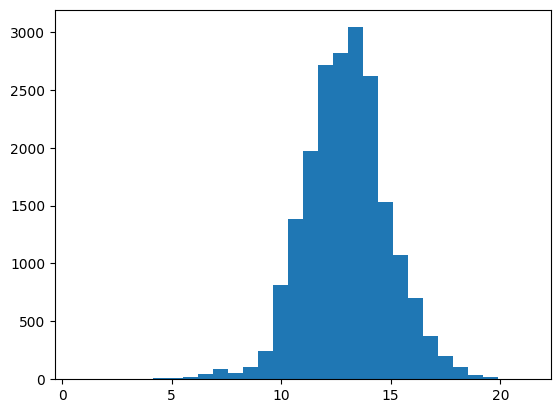

In [34]:
plt.hist(np.log1p(data["Цена"]), bins=30)
plt.show()

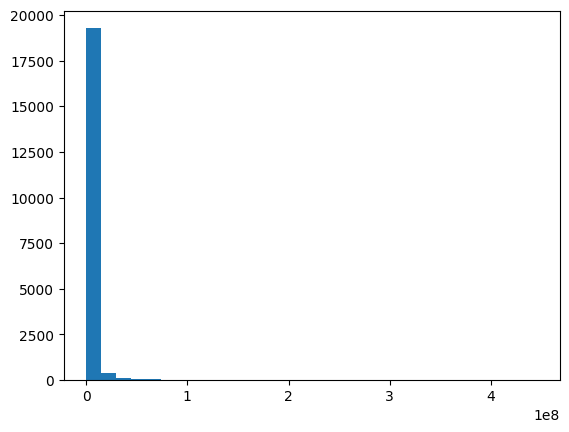

In [35]:
mask1 = (np.log1p(data["Цена"]) <= 20)
mask2 = (np.log1p(data["Цена"]) >= 4.5)
plt.hist(data["Цена"][mask1 & mask2], bins=30)
plt.show()

In [36]:
data = data[mask1 & mask2].copy()

In [37]:
data["Log(Цена)"] = np.log1p(data["Цена"])

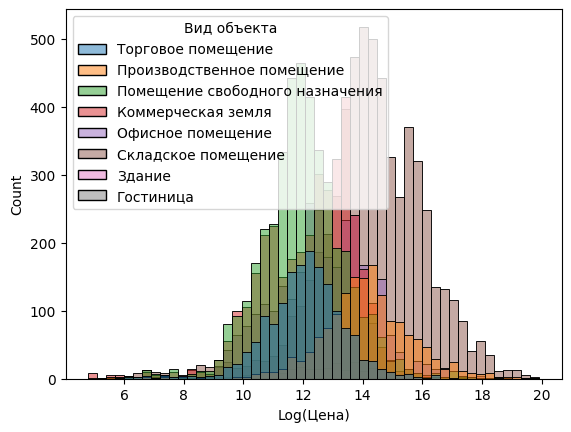

In [38]:

sns.histplot(data, x="Log(Цена)", hue="Вид объекта", bins=50)
plt.show()

In [39]:
data["Log(Цена)"] = np.log1p(data["Цена"])

In [40]:
mask1 = (np.log1p(data["Цена"]) <= 17)
mask2 = (np.log1p(data["Цена"]) >= 10)
dfg = data[mask1 & mask2].groupby(by="Вид объекта")["Цена"].mean()
dfg.astype(int)

Вид объекта
Гостиница                          1498400
Здание                             1127769
Коммерческая земля                  558172
Офисное помещение                  1009746
Помещение свободного назначения     455242
Производственное помещение         2543126
Складское помещение                3324114
Торговое помещение                  425449
Name: Цена, dtype: int64

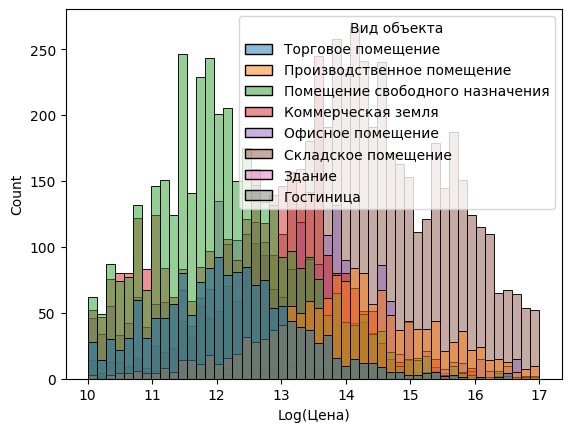

In [41]:
mask1 = (np.log1p(data["Цена"]) <= 17)
mask2 = (np.log1p(data["Цена"]) >= 10)
sns.histplot(data[mask1 & mask2], x="Log(Цена)", hue="Вид объекта", bins=50)
plt.show()

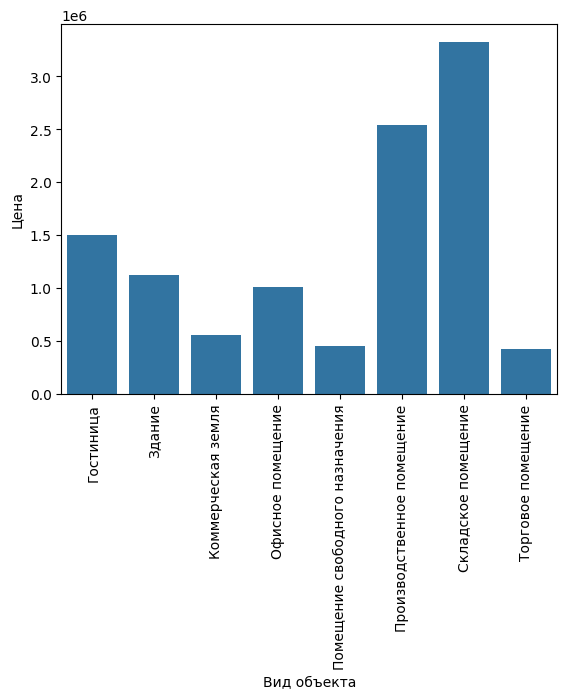

In [42]:

sns.barplot(dfg)
plt.xticks(rotation=90)
plt.show()

In [43]:
types = ["Здание", "Производственное помещение", "Складское помещение"]


In [44]:
data.head()

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Log(Цена)
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
320933693,cian.ru,"Торговая площадь в Московская область, Ленинск...",600000,2025-10-19 22:29:04,Агентство,Московская область,Ленинский городской округ,Домодедовская,"ш. Пригородное, 24",НАЗВАНИЕ: Торговая площадь в Московская област...,55.555520,37.811267,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,12.833,1.0,17.0,Торговое помещение,231.0,NaN,13.304687
318910625,cian.ru,Производственное помещение в Московская област...,2349809,2025-10-19 22:29:03,Агентство,Московская область,Пушкино,Мамонтовка,"Мамонтовка мкр, Рабочая ул., 1к1",НАЗВАНИЕ: Производственное помещение в Московс...,56.002249,37.800631,https://www.cian.ru/rent/commercial/318910625,https://images.cdn-cian.ru/images/2531003819-1...,NaN,1.0,2.0,Производственное помещение,3700.0,NaN,14.669845
320821721,cian.ru,Помещение свободного назначения в Московская о...,200000,2025-10-19 22:28:45,Агентство,Московская область,Подольск,Подольск,"ул. Мира, 7",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.421910,37.572369,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,1.500,1.0,4.0,Помещение свободного назначения,151.0,NaN,12.206078
322939017,cian.ru,"Коммерческая земля в Московская область, Дмитр...",51000,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,https://www.cian.ru/rent/commercial/322939017,https://images.cdn-cian.ru/images/2667463412-1...,NaN,NaN,NaN,Коммерческая земля,887.0,Участок поселений,10.839601
322939018,cian.ru,"Коммерческая земля в Московская область, Дмитр...",46750,2025-10-19 22:28:42,Агентство,Московская область,Дмитровский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.437228,37.061138,https://www.cian.ru/rent/commercial/322939018,https://images.cdn-cian.ru/images/2667463474-1...,NaN,NaN,NaN,Коммерческая земля,804.0,Участок поселений,10.752591


In [45]:
data[data["Общая площадь"] > 0.5e6]

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Log(Цена)
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
321758249,cian.ru,"Коммерческая земля в Московская область, Лотош...",2121,2025-10-14 04:48:44,Агентство,Московская область,Лотошино пгт,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.227315,35.639419,https://www.cian.ru/rent/commercial/321758249,https://images.cdn-cian.ru/images/2627042425-1...,NaN,NaN,NaN,Коммерческая земля,805403.0,Сельхозназначение,7.660114
321417535,cian.ru,"Коммерческая земля в Московская область, Химки...",20000,2025-09-26 14:27:26,Агентство,Московская область,Химки городской округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,55.977748,37.382349,https://www.cian.ru/rent/commercial/321417535,https://images.cdn-cian.ru/images/2614902877-1...,NaN,NaN,NaN,Коммерческая земля,1100000.0,Промназначение,9.903538
321232566,cian.ru,"Коммерческая земля в Московская область, Пущин...",79520,2025-09-23 00:34:04,Агентство,Московская область,Пущино,NaN,"Серпухов городской округ, В мкр,",НАЗВАНИЕ: Коммерческая земля в Московская обла...,54.836207,37.618785,https://www.cian.ru/rent/commercial/321232566,NaN,NaN,NaN,NaN,Коммерческая земля,994000.0,Сельхозназначение,11.283776
320088275,cian.ru,"Коммерческая земля в Московская область, Наро-...",473313,2025-09-22 22:35:49,Агентство,Московская область,Наро-Фоминский городской округ,Апрелевка,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,55.534041,36.989156,https://www.cian.ru/rent/commercial/320088275,https://images.cdn-cian.ru/images/2572782409-1...,12.833,NaN,NaN,Коммерческая земля,599131.0,Сельхозназначение,13.067514
320881118,cian.ru,"Коммерческая земля в Московская область, Ленин...",47000,2025-09-14 02:25:07,Агентство,Московская область,Ленинский городской округ,Домодедовская,Приозерный жилой комплекс,НАЗВАНИЕ: Коммерческая земля в Московская обла...,55.582609,37.742878,https://www.cian.ru/rent/commercial/320881118,https://images.cdn-cian.ru/images/2597399626-1...,5.500,NaN,NaN,Коммерческая земля,1340000.0,Сельхозназначение,10.757924
319434549,cian.ru,"Коммерческая земля в Московская область, Клин ...",250313,2025-09-13 14:26:31,Агентство,Московская область,Клин городской округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,56.387420,36.775519,https://www.cian.ru/rent/commercial/319434549,https://images.cdn-cian.ru/images/2551042820-1...,NaN,NaN,NaN,Коммерческая земля,5043800.0,Сельхозназначение,12.430471
321089873,cian.ru,"Коммерческая земля в Московская область, Пущин...",36120,2025-09-13 00:25:37,Агентство,Московская область,Пущино,NaN,"Серпухов городской округ, В мкр,",НАЗВАНИЕ: Коммерческая земля в Московская обла...,54.836207,37.618785,https://www.cian.ru/rent/commercial/321089873,NaN,NaN,NaN,NaN,Коммерческая земля,514851.0,Сельхозназначение,10.494630
321564560,cian.ru,"Коммерческая земля в Московская область, Одинц...",30140,2025-09-05 22:24:28,Агентство,Московская область,Одинцовский городской округ,Крылатское,Срезка на 5 км,НАЗВАНИЕ: Коммерческая земля в Московская обла...,55.747885,37.361939,https://www.cian.ru/rent/commercial/321564560,NaN,14.667,NaN,NaN,Коммерческая земля,839000.0,Сельхозназначение,10.313642
321151955,cian.ru,"Коммерческая земля в Московская область, Егорь...",300000000,2025-09-05 12:24:10,Частное лицо (фильтр),Московская область,Егорьевск,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,55.383055,39.035842,https://www.cian.ru/rent/commercial/321151955,https://images.cdn-cian.ru/images/kommercheski...,NaN,NaN,NaN,Коммерческая земля,30000000.0,NaN,19.519293


# Stop graf

In [46]:
data[data["Общая площадь"] > 4000]

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Log(Цена)
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
321049362,cian.ru,"Склад в Московская область, Жуковский 92к5 (21...",27950000,2025-10-19 16:28:14,Агентство,Московская область,Жуковский,Кратово,92к5,"НАЗВАНИЕ: Склад в Московская область, Жуковски...",55.575948,38.055645,https://www.cian.ru/rent/commercial/321049362,https://images.cdn-cian.ru/images/2614972139-1...,11.917,1.0,2.0,Складское помещение,21500.0,NaN,17.145928
321947537,cian.ru,Производственное помещение в Московская област...,1360000,2025-10-19 16:27:59,Агентство,Московская область,Ступино городской округ,NaN,NaN,НАЗВАНИЕ: Производственное помещение в Московс...,54.992100,38.276478,https://www.cian.ru/rent/commercial/321947537,https://images.cdn-cian.ru/images/2633195213-1...,NaN,1.0,1.0,Производственное помещение,6800.0,NaN,14.122996
321947533,cian.ru,Производственное помещение в Московская област...,1020000,2025-10-19 16:27:59,Агентство,Московская область,Ступино городской округ,NaN,NaN,НАЗВАНИЕ: Производственное помещение в Московс...,54.992100,38.276478,https://www.cian.ru/rent/commercial/321947533,https://images.cdn-cian.ru/images/2633195185-1...,NaN,1.0,1.0,Производственное помещение,5100.0,NaN,13.835314
321947532,cian.ru,"Склад в Московская область, Ступино городской ...",1020000,2025-10-19 16:27:59,Агентство,Московская область,Ступино городской округ,NaN,NaN,"НАЗВАНИЕ: Склад в Московская область, Ступино ...",54.992100,38.276478,https://www.cian.ru/rent/commercial/321947532,https://images.cdn-cian.ru/images/2633195171-1...,NaN,1.0,1.0,Складское помещение,5100.0,NaN,13.835314
321947534,cian.ru,"Склад в Московская область, Ступино городской ...",1360000,2025-10-19 16:27:58,Агентство,Московская область,Ступино городской округ,NaN,NaN,"НАЗВАНИЕ: Склад в Московская область, Ступино ...",54.992100,38.276478,https://www.cian.ru/rent/commercial/321947534,https://images.cdn-cian.ru/images/2633195195-1...,NaN,1.0,1.0,Складское помещение,6800.0,NaN,14.122996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319562636,cian.ru,"Коммерческая земля в Московская область, Можай...",2311,2025-07-31 00:24:44,Агентство,Московская область,Можайский муниципальный округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,55.557943,35.919891,https://www.cian.ru/rent/commercial/319562636,NaN,NaN,NaN,NaN,Коммерческая земля,69100.0,Сельхозназначение,7.745868
319562650,cian.ru,"Коммерческая земля в Московская область, Колом...",9169,2025-07-31 00:24:44,Агентство,Московская область,Коломна городской округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,54.983721,38.523568,https://www.cian.ru/rent/commercial/319562650,NaN,NaN,NaN,NaN,Коммерческая земля,274184.0,Сельхозназначение,9.123693
319562651,cian.ru,"Коммерческая земля в Московская область, Колом...",228,2025-07-31 00:24:43,Агентство,Московская область,Коломна городской округ,NaN,NaN,НАЗВАНИЕ: Коммерческая земля в Московская обла...,54.983721,38.523568,https://www.cian.ru/rent/commercial/319562651,NaN,NaN,NaN,NaN,Коммерческая земля,6821.0,Сельхозназначение,5.433722


In [47]:
data = data[data["Вид объекта"] != "Складское помещение"].copy()
data = data[data["Вид объекта"] != "Производственное помещение"].copy()
data = data[data["Вид объекта"] != "Офисное помещение"].copy()
data = data[data["Вид объекта"] != "Коммерческая земля"].copy()
data = data[data["Вид объекта"] != "Гостиница"].copy()
#data = data[data["Вид объекта"] != "Здание"].copy()
data = data[data["Общая площадь"] <= 2000].copy()
data = data[data["Общая площадь"] >= 20].copy()

In [48]:
data[data["Цена"] > 2e8]

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Log(Цена)
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
322881779,cian.ru,"Здание в Московская область, Дмитровский муниц...",360000000,2025-10-14 16:27:52,Частное лицо (фильтр),Московская область,Дмитровский муниципальный округ,NaN,NaN,"НАЗВАНИЕ: Здание в Московская область, Дмитров...",56.496691,37.798529,https://www.cian.ru/rent/commercial/322881779,https://images.cdn-cian.ru/images/zdanie-novoe...,NaN,NaN,1.0,Здание,1200.0,NaN,19.701615
322329506,cian.ru,"Здание в Московская область, Рузский муниципал...",445500000,2025-09-29 12:21:47,Частное лицо (фильтр),Московская область,Рузский муниципальный округ,NaN,NaN,"НАЗВАНИЕ: Здание в Московская область, Рузский...",55.550932,36.376164,https://www.cian.ru/rent/commercial/322329506,https://images.cdn-cian.ru/images/zdanie-doroh...,NaN,NaN,3.0,Здание,900.0,NaN,19.914708
318072559,cian.ru,"Торговая площадь в Московская область, Красног...",250000000,2025-08-09 12:23:38,Агентство,Московская область,Красногорск городской округ,Павшино,"ул. Заповедная, 21",НАЗВАНИЕ: Торговая площадь в Московская област...,55.770917,37.228575,https://www.cian.ru/rent/commercial/318072559,https://images.cdn-cian.ru/images/2581834454-1...,14.667,1.0,9.0,Торговое помещение,66.0,NaN,19.336971
320327012,cian.ru,"Здание в Московская область, Кашира Стрелецкая...",397100000,2025-07-31 14:25:22,Агентство,Московская область,Кашира,NaN,"Стрелецкая ул., 70","НАЗВАНИЕ: Здание в Московская область, Кашира ...",54.825789,38.147668,https://www.cian.ru/rent/commercial/320327012,https://images.cdn-cian.ru/images/zdanie-kashi...,NaN,NaN,1.0,Здание,722.0,NaN,19.799699


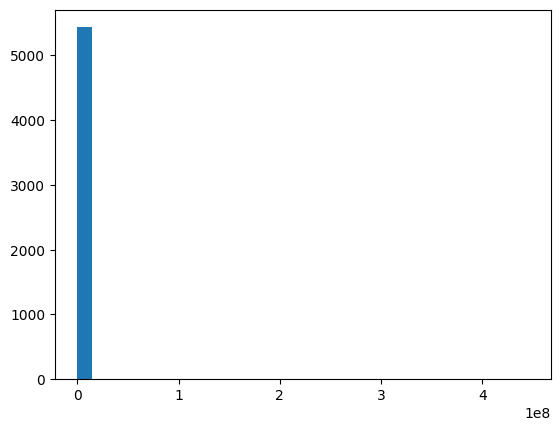

In [49]:
plt.hist(data["Цена"], bins=30)
plt.show()

In [50]:
data = data[data["Цена"] < 2e6].copy()
data = data[data["Цена"] > 20000].copy()

In [51]:
data

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Категория,Log(Цена)
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
320933693,cian.ru,"Торговая площадь в Московская область, Ленинск...",600000,2025-10-19 22:29:04,Агентство,Московская область,Ленинский городской округ,Домодедовская,"ш. Пригородное, 24",НАЗВАНИЕ: Торговая площадь в Московская област...,55.555520,37.811267,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,12.833,1.0,17.0,Торговое помещение,231.0,NaN,13.304687
320821721,cian.ru,Помещение свободного назначения в Московская о...,200000,2025-10-19 22:28:45,Агентство,Московская область,Подольск,Подольск,"ул. Мира, 7",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.421910,37.572369,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,1.500,1.0,4.0,Помещение свободного назначения,151.0,NaN,12.206078
319368554,cian.ru,Помещение свободного назначения в Московская о...,165000,2025-10-19 22:28:38,Агентство,Московская область,Люберцы,Лухмановская,"ул. 8 Марта, 14к2",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.699695,37.880240,https://www.cian.ru/rent/commercial/319368554,https://images.cdn-cian.ru/images/nezhiloe-pom...,1.583,1.0,25.0,Помещение свободного назначения,70.0,NaN,12.013707
323058065,cian.ru,Помещение свободного назначения в Московская о...,220000,2025-10-19 22:28:37,Агентство,Московская область,Котельники,Котельники,"Парковый мкр, 1к20",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.656956,37.874850,https://www.cian.ru/rent/commercial/323058065,https://images.cdn-cian.ru/images/nezhiloe-pom...,9.167,1.0,15.0,Помещение свободного назначения,89.0,NaN,12.301387
321288658,cian.ru,"Торговая площадь в Московская область, Люберцы...",190000,2025-10-19 16:28:13,Агентство,Московская область,Люберцы,Ухтомская,"ул. 8 Марта, 12к1",НАЗВАНИЕ: Торговая площадь в Московская област...,55.698335,37.879507,https://www.cian.ru/rent/commercial/321288658,https://images.cdn-cian.ru/images/2640001011-1...,1.167,1.0,25.0,Торговое помещение,96.0,NaN,12.154785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320292043,cian.ru,Помещение свободного назначения в Московская о...,230000,2025-07-30 16:24:32,Агентство,Московская область,Одинцово,4-й,"Можайское ш., 71В",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.678326,37.281872,https://www.cian.ru/rent/commercial/320292043,https://images.cdn-cian.ru/images/2579185890-1...,NaN,2.0,2.0,Помещение свободного назначения,165.0,NaN,12.345839
320174530,cian.ru,Помещение свободного назначения в Московская о...,170000,2025-07-30 16:24:31,Агентство,Московская область,Раменский муниципальный округ,NaN,"ул. Дальняя, 65",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.385326,38.206238,https://www.cian.ru/rent/commercial/320174530,https://images.cdn-cian.ru/images/2575345371-1...,NaN,1.0,1.0,Помещение свободного назначения,173.0,NaN,12.043560
320292087,cian.ru,Помещение свободного назначения в Московская о...,35000,2025-07-30 16:24:31,Агентство,Московская область,Одинцово,4-й,"Можайское ш., 71В",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.678326,37.281872,https://www.cian.ru/rent/commercial/320292087,https://images.cdn-cian.ru/images/2579185300-1...,NaN,2.0,2.0,Помещение свободного назначения,20.0,NaN,10.463132


In [52]:
data.drop("Категория", axis=1) 

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Log(Цена)
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
320933693,cian.ru,"Торговая площадь в Московская область, Ленинск...",600000,2025-10-19 22:29:04,Агентство,Московская область,Ленинский городской округ,Домодедовская,"ш. Пригородное, 24",НАЗВАНИЕ: Торговая площадь в Московская област...,55.555520,37.811267,https://www.cian.ru/rent/commercial/320933693,https://images.cdn-cian.ru/images/2598997160-1...,12.833,1.0,17.0,Торговое помещение,231.0,13.304687
320821721,cian.ru,Помещение свободного назначения в Московская о...,200000,2025-10-19 22:28:45,Агентство,Московская область,Подольск,Подольск,"ул. Мира, 7",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.421910,37.572369,https://www.cian.ru/rent/commercial/320821721,https://images.cdn-cian.ru/images/2595423867-1...,1.500,1.0,4.0,Помещение свободного назначения,151.0,12.206078
319368554,cian.ru,Помещение свободного назначения в Московская о...,165000,2025-10-19 22:28:38,Агентство,Московская область,Люберцы,Лухмановская,"ул. 8 Марта, 14к2",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.699695,37.880240,https://www.cian.ru/rent/commercial/319368554,https://images.cdn-cian.ru/images/nezhiloe-pom...,1.583,1.0,25.0,Помещение свободного назначения,70.0,12.013707
323058065,cian.ru,Помещение свободного назначения в Московская о...,220000,2025-10-19 22:28:37,Агентство,Московская область,Котельники,Котельники,"Парковый мкр, 1к20",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.656956,37.874850,https://www.cian.ru/rent/commercial/323058065,https://images.cdn-cian.ru/images/nezhiloe-pom...,9.167,1.0,15.0,Помещение свободного назначения,89.0,12.301387
321288658,cian.ru,"Торговая площадь в Московская область, Люберцы...",190000,2025-10-19 16:28:13,Агентство,Московская область,Люберцы,Ухтомская,"ул. 8 Марта, 12к1",НАЗВАНИЕ: Торговая площадь в Московская област...,55.698335,37.879507,https://www.cian.ru/rent/commercial/321288658,https://images.cdn-cian.ru/images/2640001011-1...,1.167,1.0,25.0,Торговое помещение,96.0,12.154785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320292043,cian.ru,Помещение свободного назначения в Московская о...,230000,2025-07-30 16:24:32,Агентство,Московская область,Одинцово,4-й,"Можайское ш., 71В",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.678326,37.281872,https://www.cian.ru/rent/commercial/320292043,https://images.cdn-cian.ru/images/2579185890-1...,NaN,2.0,2.0,Помещение свободного назначения,165.0,12.345839
320174530,cian.ru,Помещение свободного назначения в Московская о...,170000,2025-07-30 16:24:31,Агентство,Московская область,Раменский муниципальный округ,NaN,"ул. Дальняя, 65",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.385326,38.206238,https://www.cian.ru/rent/commercial/320174530,https://images.cdn-cian.ru/images/2575345371-1...,NaN,1.0,1.0,Помещение свободного назначения,173.0,12.043560
320292087,cian.ru,Помещение свободного назначения в Московская о...,35000,2025-07-30 16:24:31,Агентство,Московская область,Одинцово,4-й,"Можайское ш., 71В",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.678326,37.281872,https://www.cian.ru/rent/commercial/320292087,https://images.cdn-cian.ru/images/2579185300-1...,NaN,2.0,2.0,Помещение свободного назначения,20.0,10.463132


In [53]:
data["Вид объекта"] = data["Вид объекта"].fillna("Неизвестно")

In [88]:
dfg = data.groupby(by="Вид объекта")["Цена"].mean()
dfg

Вид объекта
Здание                             484127.764103
Неизвестно                         418952.380952
Помещение свободного назначения    291611.227286
Торговое помещение                 306569.159682
Name: Цена, dtype: float64

In [67]:
data[[data["Тип автора"]].unique()

array(['Агентство', 'Частное лицо (фильтр)', 'Частное лицо'], dtype=object)

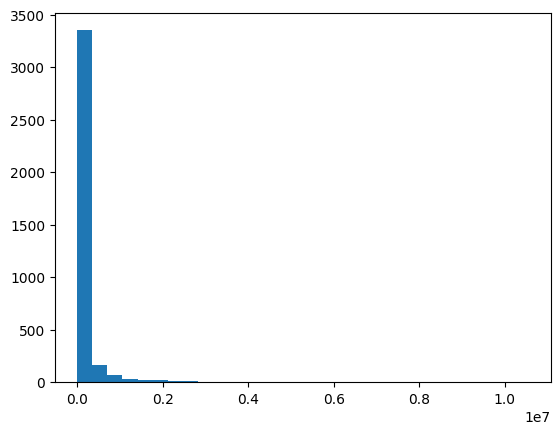

In [98]:
dfg = data["Цена"] / data["Расстояние до метро, км"]
dfg.dropna()
plt.hist(dfg, bins=30)
plt.show()

In [ ]:
data.reanme